# Rigorous GPU Notebook: Clinical + Anthropometric Data

This notebook loads datasets from the `Datasets` folder (clinical and anthropometric only), merges them, and applies the same rigorous training pipeline:

**Workflow:**
1. Dataset discovery and merging (clinical ← anthropometric)
2. Target inference (hypertension) with BP fallback
3. Feature engineering (smoking, alcohol, BMI, WHR)
4. Manual dropping and protection of age/sex
5. EDA with correlation heatmaps
6. KNN imputation + scaling + encoding + collinearity filtering
7. Two-stage GPU optimization (RF, XGBoost, CatBoost)
8. CPU model search (AdaBoost, KNN, Naive Bayes, Logistic Regression)
9. Calibration (base, Platt, Isotonic, Venn-Abers)
10. SHAP and LIME explanations


In [1]:
# Optional install (uncomment if needed), then restart kernel once.
%pip install -q numpy pandas scipy scikit-learn joblib xgboost catboost venn-abers seaborn matplotlib imbalanced-learn torch shap lime
%pip install -q cuml-cu13 --extra-index-url=https://pypi.nvidia.com

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [3]:
import json
import random
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, loguniform

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)

xgb_available = True
cat_available = True
venn_available = True
torch_available = True
torch_cuda_available = False
cuml_available = True

try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    cat_available = False
    CatBoostClassifier = None

try:
    from venn_abers import VennAbers
except Exception:
    venn_available = False
    VennAbers = None

try:
    import torch
    torch_cuda_available = bool(torch.cuda.is_available())
except Exception:
    torch_available = False

try:
    from cuml.ensemble import RandomForestClassifier as cuRFClassifier
except Exception:
    cuml_available = False
    cuRFClassifier = None

print({
    'xgboost': xgb_available,
    'catboost': cat_available,
    'venn_abers': venn_available,
    'torch': torch_available,
    'torch_cuda': torch_cuda_available,
    'cuml_rf': cuml_available,
})

{'xgboost': True, 'catboost': True, 'venn_abers': True, 'torch': True, 'torch_cuda': True, 'cuml_rf': True}


In [4]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'datasets_clin_anthro_gpu_artifacts'
MODEL_DIR = ARTIFACT_DIR / 'models'

for p in [ARTIFACT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TARGET_CANDIDATES = ['hypertension', 'htn', 'target', 'label', 'outcome']
COLLINEARITY_CUTOFF = 0.70

STAGE1_EPOCHS = 120
STAGE2_EPOCHS = 300
FINAL_EPOCHS = 900

STAGE1_TRIALS_PER_MODEL = 180
STAGE2_REFINEMENTS_PER_TOP_CONFIG = 24
TOP_K_STAGE1 = 8
TOP_K_STAGE2 = 3
CV_FOLDS_STAGE1 = 5
CV_FOLDS_STAGE2 = 6

USE_GPU_WHEN_AVAILABLE = True
N_JOBS = -1

print('Artifacts:', ARTIFACT_DIR)
print('Configuration: COLLINEARITY_CUTOFF={}, STAGE1_EPOCHS={}, STAGE2_EPOCHS={}, FINAL_EPOCHS={}'.format(
    COLLINEARITY_CUTOFF, STAGE1_EPOCHS, STAGE2_EPOCHS, FINAL_EPOCHS
))

Artifacts: /workspace/Thesis-part-2/datasets_clin_anthro_gpu_artifacts
Configuration: COLLINEARITY_CUTOFF=0.7, STAGE1_EPOCHS=120, STAGE2_EPOCHS=300, FINAL_EPOCHS=900


In [5]:
def _normalize_join_columns(df_in):
    rename_map = {}
    col_lc = {c.lower(): c for c in df_in.columns}
    for key in ['hhnum', 'member_code']:
        if key in col_lc and col_lc[key] != key:
            rename_map[col_lc[key]] = key
    return df_in.rename(columns=rename_map)

def _find_dataset_from_folder(folder_path, dataset_type='clinical'):
    """Find the data-set CSV (not dictionary) from a dataset folder."""
    if not folder_path.exists():
        return None
    csv_paths = sorted([p for p in folder_path.glob('*.csv') if 'dictionary' not in p.name.lower()])
    preferred = [p for p in csv_paths if ('data-set' in p.name.lower()) or ('dataset' in p.name.lower())]
    return (preferred + csv_paths)[0] if (preferred + csv_paths) else None

def discover_and_merge_datasets_from_folder(dataset_folder_path):
    """
    Discover clinical and anthropometric datasets in the Datasets folder,
    and merge them: clinical <- anthropometric.
    """
    dataset_folder = Path(dataset_folder_path)
    if not dataset_folder.exists():
        raise FileNotFoundError(f'Datasets folder not found: {dataset_folder}')
    
    # Discover datasets
    clinical_path = _find_dataset_from_folder(dataset_folder / 'Clinical', 'clinical')
    anthro_path = _find_dataset_from_folder(dataset_folder / 'Anthro', 'anthro')
    
    print(f'Discovered clinical: {clinical_path}')
    print(f'Discovered anthropometric: {anthro_path}')
    
    # Load clinical
    clinical_df = pd.read_csv(clinical_path) if clinical_path else None
    if clinical_df is None:
        raise ValueError('Could not load clinical dataset')
    
    clinical_df = _normalize_join_columns(clinical_df)
    print(f'Loaded clinical: {clinical_df.shape}')
    
    # Merge with anthropometric (left join on merged clinical)
    if anthro_path:
        anthro_df = pd.read_csv(anthro_path)
        anthro_df = _normalize_join_columns(anthro_df)
        join_keys = [k for k in ['hhnum', 'member_code'] if k in clinical_df.columns and k in anthro_df.columns]
        if join_keys:
            anthro_df = anthro_df.drop_duplicates(subset=join_keys, keep='first')
            overlap = [c for c in anthro_df.columns if c in clinical_df.columns and c not in join_keys]
            if overlap:
                anthro_df = anthro_df.rename(columns={c: f'{c}_anthro' for c in overlap})
            clinical_df = clinical_df.merge(anthro_df, on=join_keys, how='left')
            print(f'Merged with anthropometric on {join_keys}: {clinical_df.shape}')
    
    return clinical_df

# Discover and merge datasets
dataset_folder = PROJECT_ROOT / 'Datasets'
df = discover_and_merge_datasets_from_folder(dataset_folder)
print(f'\nFinal merged shape: {df.shape}')
print(f'Columns: {df.shape[1]}')

Discovered clinical: /workspace/Thesis-part-2/Datasets/Clinical/Jonathan Ralph_Baes_2025-09-18020631_data-set_clinical.csv
Discovered anthropometric: /workspace/Thesis-part-2/Datasets/Anthro/Jonathan Ralph_Baes_2025-09-29103911_data-set_anthrop.csv


Loaded clinical: (351701, 29)
Merged with anthropometric on ['hhnum', 'member_code']: (351701, 45)

Final merged shape: (351701, 45)
Columns: 45


In [6]:
def infer_target_column(df, candidates):
    lc = {c.lower(): c for c in df.columns}
    for t in candidates:
        if t.lower() in lc:
            return lc[t.lower()]
    for c in df.columns:
        c_lc = c.lower()
        if any(t.lower() in c_lc for t in candidates):
            return c
    return None

def infer_bp_columns(df):
    sbp_aliases = ['ave_sbp', 'sbp', 'systolic', 'sysbp', 's_bp']
    dbp_aliases = ['ave_dbp', 'dbp', 'diastolic', 'diabp', 'd_bp']
    lc = {c.lower(): c for c in df.columns}
    
    sbp_col = None
    for a in sbp_aliases:
        if a in lc:
            sbp_col = lc[a]
            break
    if sbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in sbp_aliases):
                sbp_col = c
                break
    
    dbp_col = None
    for a in dbp_aliases:
        if a in lc:
            dbp_col = lc[a]
            break
    if dbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in dbp_aliases):
                dbp_col = c
                break
    
    return sbp_col, dbp_col

def find_first_column_case_insensitive(columns, candidates):
    lc = {c.lower(): c for c in columns}
    for cand in candidates:
        cand_lc = cand.lower()
        if cand_lc in lc:
            return lc[cand_lc]
    for c in columns:
        c_lc = c.lower()
        if any(cand.lower() in c_lc for cand in candidates):
            return c
    return None

def to_numeric_clean(series):
    s = pd.to_numeric(series, errors='coerce')
    return s.where(~s.isin([9, 99, 888888, 999999]), np.nan)

# Target inference
target_col = infer_target_column(df, TARGET_CANDIDATES)
TARGET_DEFINED_FROM_BP = False
TARGET_SOURCE_COLUMNS = []

if target_col is None:
    sbp_col, dbp_col = infer_bp_columns(df)
    if sbp_col is not None and dbp_col is not None:
        sbp = pd.to_numeric(df[sbp_col], errors='coerce')
        dbp = pd.to_numeric(df[dbp_col], errors='coerce')
        df['Hypertension'] = (((sbp >= 130) | (dbp >= 80)).fillna(False)).astype(int)
        target_col = 'Hypertension'
        TARGET_DEFINED_FROM_BP = True
        TARGET_SOURCE_COLUMNS = [sbp_col, dbp_col]
        print(f'Target column created from: {sbp_col}, {dbp_col}')
    else:
        raise ValueError('Could not infer target and could not derive Hypertension from SBP/DBP (130/80 OR rule).')

df = df.dropna(subset=[target_col]).copy()
y_raw = df[target_col]
if y_raw.nunique() != 2:
    raise ValueError(f'Target must be binary. Found {y_raw.nunique()} classes.')

if y_raw.dtype == 'O':
    y = pd.Series(LabelEncoder().fit_transform(y_raw.astype(str)), index=y_raw.index, name=target_col)
else:
    y = pd.Series(y_raw.astype(int), index=y_raw.index, name=target_col)

X = df.drop(columns=[target_col]).copy()

print(f'Target column: {target_col}')
print(f'Target defined from BP fallback: {TARGET_DEFINED_FROM_BP}')
print(f'Raw rows: {len(df)}')
print(f'Class balance: {y.value_counts(normalize=True).to_dict()}')

Target column created from: Ave_SBP, Ave_DBP


Target column: Hypertension
Target defined from BP fallback: True
Raw rows: 351701
Class balance: {0: 0.6732423280002047, 1: 0.3267576719997953}


In [7]:
def build_smoking_level_feature(df_in):
    used_cols = []
    smoking_level_col = find_first_column_case_insensitive(df_in.columns, ['smoking_level'])
    smoke_status_col = find_first_column_case_insensitive(df_in.columns, ['smoke_status'])
    current_smoking_col = find_first_column_case_insensitive(df_in.columns, ['current_smoking', 'currentsmoking'])
    ever_smoke_col = find_first_column_case_insensitive(df_in.columns, ['ever_smk'])
    
    if smoking_level_col is not None:
        s = to_numeric_clean(df_in[smoking_level_col]).clip(lower=0, upper=3)
        used_cols.append(smoking_level_col)
        return s.astype(float), sorted(set(used_cols))
    
    idx = df_in.index
    smoke = pd.Series(np.nan, index=idx, dtype=float)
    
    if smoke_status_col is not None:
        status = to_numeric_clean(df_in[smoke_status_col])
        used_cols.append(smoke_status_col)
        smoke.loc[status == 0] = 0
        smoke.loc[status == 2] = 1
        smoke.loc[status == 1] = 2
        if current_smoking_col is not None:
            current = to_numeric_clean(df_in[current_smoking_col])
            used_cols.append(current_smoking_col)
            smoke.loc[(status == 1) & (current == 3)] = 3
        return smoke.astype(float), sorted(set(used_cols))
    
    if current_smoking_col is not None:
        current = to_numeric_clean(df_in[current_smoking_col])
        used_cols.append(current_smoking_col)
        smoke.loc[current == 0] = 0
        smoke.loc[current.isin([1, 2])] = 2
        smoke.loc[current == 3] = 3
        if ever_smoke_col is not None:
            ever = to_numeric_clean(df_in[ever_smoke_col])
            used_cols.append(ever_smoke_col)
            smoke.loc[(current == 0) & (ever > 0)] = 1
        return smoke.astype(float), sorted(set(used_cols))
    
    if ever_smoke_col is not None:
        ever = to_numeric_clean(df_in[ever_smoke_col])
        used_cols.append(ever_smoke_col)
        smoke.loc[ever == 0] = 0
        smoke.loc[ever > 0] = 1
        return smoke.astype(float), sorted(set(used_cols))
    
    return None, []

def build_alcohol_level_feature(df_in):
    used_cols = []
    alcohol_level_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_level'])
    alcohol_status_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_status'])
    alcohol_ever_col = find_first_column_case_insensitive(df_in.columns, ['alcohol'])
    current_alcohol_col = find_first_column_case_insensitive(df_in.columns, ['con_alcohol'])
    drink30_col = find_first_column_case_insensitive(df_in.columns, ['drnk_30days'])
    binge_col = find_first_column_case_insensitive(df_in.columns, ['binge_drink', 'binge_drinking'])
    
    if alcohol_level_col is not None:
        a = to_numeric_clean(df_in[alcohol_level_col]).clip(lower=0, upper=3)
        used_cols.append(alcohol_level_col)
        return a.astype(float), sorted(set(used_cols))
    
    idx = df_in.index
    alcohol = pd.Series(np.nan, index=idx, dtype=float)
    
    if alcohol_status_col is not None:
        status = to_numeric_clean(df_in[alcohol_status_col])
        used_cols.append(alcohol_status_col)
        alcohol.loc[status == 0] = 0
        alcohol.loc[status == 2] = 1
        alcohol.loc[status == 1] = 2
        if binge_col is not None:
            binge = to_numeric_clean(df_in[binge_col])
            used_cols.append(binge_col)
            alcohol.loc[(status == 1) & (binge == 1)] = 3
        return alcohol.astype(float), sorted(set(used_cols))
    
    alcohol.loc[:] = 0
    if alcohol_ever_col is not None:
        ever = to_numeric_clean(df_in[alcohol_ever_col])
        used_cols.append(alcohol_ever_col)
        alcohol.loc[ever > 0] = 1
    if current_alcohol_col is not None:
        current = to_numeric_clean(df_in[current_alcohol_col])
        used_cols.append(current_alcohol_col)
        alcohol.loc[current == 1] = np.maximum(alcohol.loc[current == 1], 2)
    if drink30_col is not None:
        d30 = to_numeric_clean(df_in[drink30_col])
        used_cols.append(drink30_col)
        alcohol.loc[d30 == 1] = np.maximum(alcohol.loc[d30 == 1], 2)
    if binge_col is not None:
        binge = to_numeric_clean(df_in[binge_col])
        used_cols.append(binge_col)
        alcohol.loc[binge == 1] = 3
    
    if used_cols:
        return alcohol.astype(float), sorted(set(used_cols))
    
    return None, []

def build_bmi_feature(df_in):
    weight_col = find_first_column_case_insensitive(df_in.columns, ['weight'])
    height_col = find_first_column_case_insensitive(df_in.columns, ['height'])
    if weight_col is None or height_col is None:
        return None, []
    w = pd.to_numeric(df_in[weight_col], errors='coerce')
    h = pd.to_numeric(df_in[height_col], errors='coerce')
    h_m = h.copy()
    if pd.notna(h_m.median(skipna=True)) and float(h_m.median(skipna=True)) > 3.0:
        h_m = h_m / 100.0
    bmi = w / (h_m ** 2)
    bmi = bmi.replace([np.inf, -np.inf], np.nan)
    return bmi.astype(float), [weight_col, height_col]

def build_whr_feature(df_in):
    waist_col = find_first_column_case_insensitive(df_in.columns, ['waist'])
    hip_col = find_first_column_case_insensitive(df_in.columns, ['hip'])
    if waist_col is None or hip_col is None:
        return None, []
    waist = pd.to_numeric(df_in[waist_col], errors='coerce')
    hip = pd.to_numeric(df_in[hip_col], errors='coerce').replace(0, np.nan)
    whr = (waist / hip).replace([np.inf, -np.inf], np.nan)
    return whr.astype(float), [waist_col, hip_col]

# Build engineered features
smoking_feature, smoking_sources = build_smoking_level_feature(X)
if smoking_feature is not None:
    X['fe_smoking_level'] = smoking_feature

alcohol_feature, alcohol_sources = build_alcohol_level_feature(X)
if alcohol_feature is not None:
    X['fe_alcohol_level'] = alcohol_feature

bmi_feature, bmi_sources = build_bmi_feature(X)
if bmi_feature is not None:
    X['bmi'] = bmi_feature

whr_feature, whr_sources = build_whr_feature(X)
if whr_feature is not None:
    X['whr'] = whr_feature

print(f'Added engineered features: smoking_level, alcohol_level, bmi, whr')

Added engineered features: smoking_level, alcohol_level, bmi, whr


In [8]:
# Drop non-predictive and behavior/anthropometric source columns
behavior_raw_candidates = [
    'current_smoking', 'currentsmoking', 'ever_smk', 'smoke_status', 'smoking_level',
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num', 'alcohol_status',
    'binge_drink', 'binge_drinking', 'alcohol_level',
]
x_lc = {c.lower(): c for c in X.columns}
behavior_drop = sorted({x_lc[c.lower()] for c in behavior_raw_candidates if c.lower() in x_lc})
if behavior_drop:
    X = X.drop(columns=behavior_drop, errors='ignore')

anthro_source_drop = sorted({
    c for c in set((bmi_sources or []) + (whr_sources or []))
    if c in X.columns and c.lower() not in {'bmi', 'whr'}
})
if anthro_source_drop:
    X = X.drop(columns=anthro_source_drop, errors='ignore')

NON_REMOVABLE_BASE_ALIASES = ['age', 'sex']

manual_non_predictive = [
    'regcode', 'provcode', 'provhuc', 'psc', 'csc', 'rhc', 'psurec', 'strrec',
    'wgts', 'fwgt', 'finalwgt', 'finalwgt1', 'finalwgt4',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'ms_psucode', 'enns_year', 'wrkplace',
    'interview_status', 'intdate', 'enumcode',
    'hhnum', 'member_code',
    'ave_sbp', 'ave_dbp', 'sbp', 'dbp', 'systolic', 'diastolic', 'sysbp', 'diabp',
    'blood_pressure',
    'height', 'weight', 'waist', 'hip',
]
x_lc = {c.lower(): c for c in X.columns}
manual_drop = sorted({x_lc[c.lower()] for c in manual_non_predictive if c.lower() in x_lc})

protected_base_cols = []
for col in X.columns:
    col_lc = col.lower()
    if any(alias in col_lc for alias in NON_REMOVABLE_BASE_ALIASES):
        protected_base_cols.append(col)
protected_base_cols = sorted(set(protected_base_cols))

if manual_drop:
    protected_drop = [c for c in manual_drop if c in protected_base_cols]
    if protected_drop:
        print('Manual-drop protection triggered for non-removable base features:', protected_drop)
    manual_drop = [c for c in manual_drop if c not in protected_base_cols]
    X = X.drop(columns=manual_drop, errors='ignore')

base_removed_non_removable = []
for alias in NON_REMOVABLE_BASE_ALIASES:
    if not any(alias in c.lower() for c in X.columns):
        base_removed_non_removable.append(alias)

RETRAIN_REQUIRED_NON_REMOVABLE = len(base_removed_non_removable) > 0

print(f'Features after manual preprocessing: {X.shape[1]}')
print(f'Manual dropped columns: {len(manual_drop)}')
print(f'Behavior raw dropped columns: {len(behavior_drop)}')
print(f'Anthropometric source dropped columns: {len(anthro_source_drop)}')
print('Protected non-removable base columns:', protected_base_cols)
print('Missing non-removable base aliases after base preprocessing:', base_removed_non_removable)

Features after manual preprocessing: 22
Manual dropped columns: 14
Behavior raw dropped columns: 9
Anthropometric source dropped columns: 4
Protected non-removable base columns: []
Missing non-removable base aliases after base preprocessing: ['age', 'sex']


Numeric columns for EDA: 21


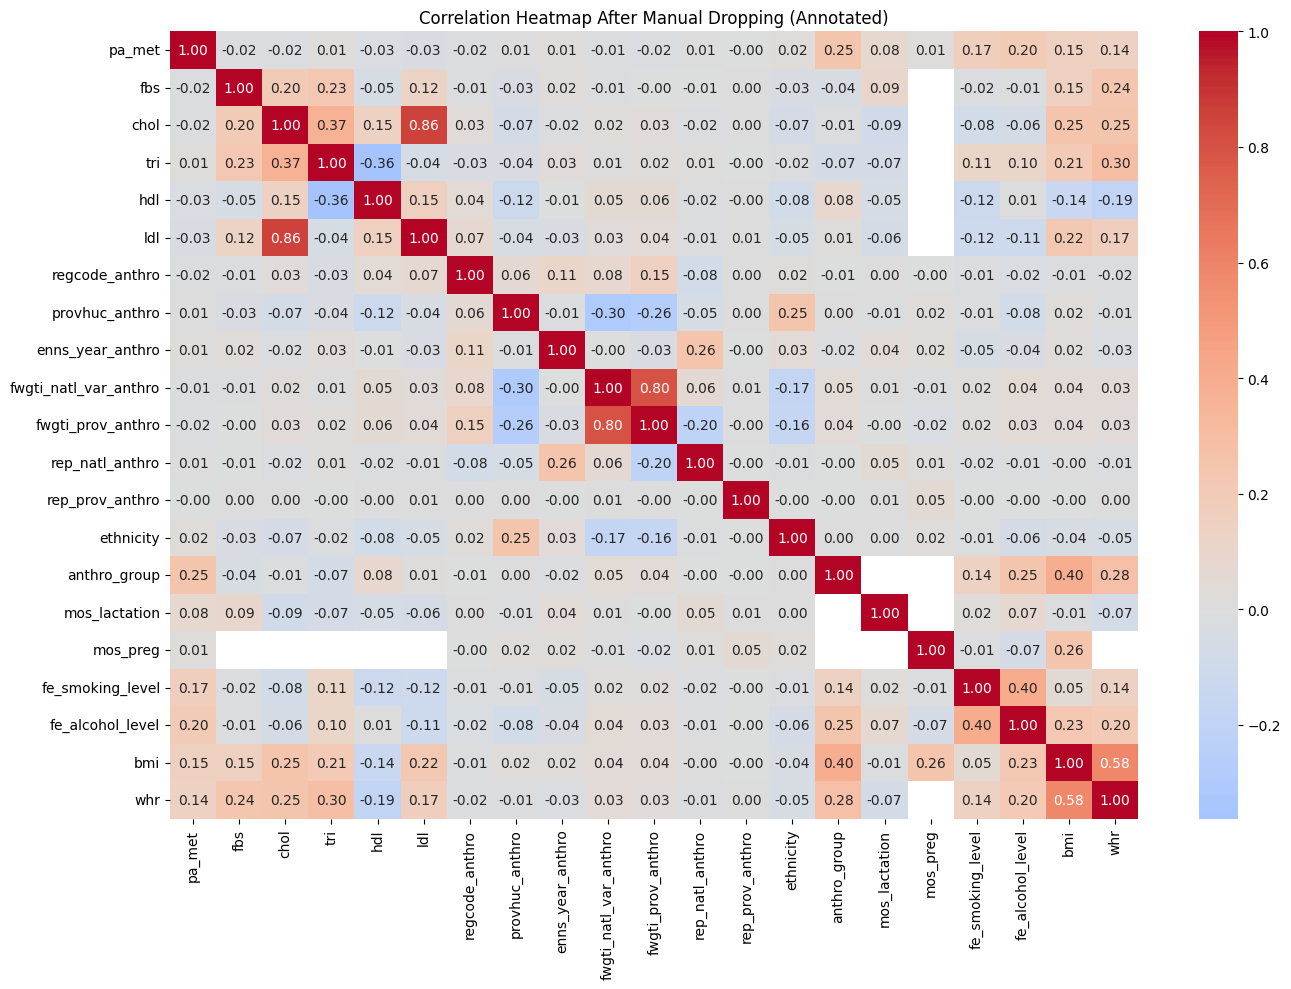

In [9]:
# EDA after manual dropping (before model matrix collinearity filtering)
num_cols_manual = X.select_dtypes(include=[np.number]).columns.tolist()

print('Numeric columns for EDA:', len(num_cols_manual))

if len(num_cols_manual) > 1:
    corr_manual = X[num_cols_manual].corr(numeric_only=True)
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_manual, cmap='coolwarm', center=0, annot=True, fmt='.2f')
    plt.title('Correlation Heatmap After Manual Dropping (Annotated)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns to plot manual-drop heatmap.')

In [ ]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_tmp
)

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

# Force categorical columns to consistent object/string values with np.nan missings.
# This avoids mixed int/str categories and pd.NA ambiguity in SimpleImputer.
for _df in (X_train, X_valid, X_test):
    for c in cat_cols:
        s = _df[c].astype('object')
        _df[c] = s.map(lambda v: (str(v).strip() if pd.notna(v) else np.nan))

numeric_pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_ohe()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols),
    ],
    remainder='drop',
)

X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)
X_test_proc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_valid_proc = pd.DataFrame(X_valid_proc, columns=feature_names, index=X_valid.index)
X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

NON_REMOVABLE_PROCESSED_ALIASES = ['age', 'sex']
non_removable_processed_cols = []
for c in X_train_proc.columns:
    c_lc = c.lower()
    if any(alias in c_lc for alias in NON_REMOVABLE_PROCESSED_ALIASES):
        non_removable_processed_cols.append(c)
non_removable_processed_cols = sorted(set(non_removable_processed_cols))

# Only enforce aliases that were available before collinearity filtering.
required_non_removable_aliases = []
for alias in NON_REMOVABLE_PROCESSED_ALIASES:
    if any(alias in c.lower() for c in X_train_proc.columns):
        required_non_removable_aliases.append(alias)

protected_cols = sorted(set([c for c in ['num__bmi', 'num__whr'] if c in X_train_proc.columns] + non_removable_processed_cols))

def collinearity_filter(df_in, cutoff=0.70, protected=None):
    protected_set = set(protected or [])
    corr = df_in.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = []
    for c in upper.columns:
        if c in protected_set:
            continue
        if (upper[c] > cutoff).any():
            drop_cols.append(c)
    keep_cols = [c for c in df_in.columns if c not in drop_cols]
    return keep_cols, drop_cols

keep_cols, dropped_cols = collinearity_filter(
    X_train_proc, cutoff=COLLINEARITY_CUTOFF, protected=protected_cols
)

missing_non_removable_after_filter = [c for c in non_removable_processed_cols if c not in keep_cols]
if missing_non_removable_after_filter:
    keep_cols = keep_cols + missing_non_removable_after_filter
    dropped_cols = [c for c in dropped_cols if c not in set(missing_non_removable_after_filter)]
    RETRAIN_REQUIRED_NON_REMOVABLE = True

X_train_final = X_train_proc[keep_cols].copy()
X_valid_final = X_valid_proc[keep_cols].copy()
X_test_final = X_test_proc[keep_cols].copy()

missing_non_removable_final = []
for alias in required_non_removable_aliases:
    if not any(alias in c.lower() for c in X_train_final.columns):
        missing_non_removable_final.append(alias)

if missing_non_removable_final:
    RETRAIN_REQUIRED_NON_REMOVABLE = True
    raise ValueError(
        f'Non-removable feature aliases missing from final matrix: {missing_non_removable_final}. '
        'Please verify source columns for age/sex are present before training.'
    )

print('Train/Valid/Test shapes:', X_train_final.shape, X_valid_final.shape, X_test_final.shape)
print('Protected cols:', protected_cols)
print('Non-removable processed cols:', non_removable_processed_cols)
print('Required non-removable aliases:', required_non_removable_aliases)
print('Missing non-removable after collinearity filter (recovered):', missing_non_removable_after_filter)
print(f'Collinearity dropped: {len(dropped_cols)}')

ValueError: Non-removable feature aliases missing from final matrix: ['age', 'sex']. Please verify source columns for age/sex are present before training.

In [ ]:
# Heatmap after collinearity-based dropping (no numbers, colors only)
if X_train_final.shape[1] > 1:
    corr_final = X_train_final.corr(numeric_only=True)
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_final, cmap='coolwarm', center=0, annot=False, cbar=True)
    plt.title('Correlation Heatmap After Collinearity Filtering (Colors Only)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough final features to plot post-collinearity heatmap.')

In [ ]:
MODEL_SPACES = {
    'random_forest': {
        'max_depth': [None, 6, 8, 12, 16, 22],
        'min_samples_split': randint(2, 24),
        'min_samples_leaf': randint(1, 12),
        'max_features': ['sqrt', 'log2', 0.4, 0.6, 0.8],
    },
    'xgboost': {
        'learning_rate': uniform(0.01, 0.24),
        'max_depth': randint(3, 11),
        'subsample': uniform(0.60, 0.40),
        'colsample_bytree': uniform(0.60, 0.40),
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0.0, 2.0),
        'reg_lambda': loguniform(1e-3, 30),
    },
    'catboost': {
        'learning_rate': uniform(0.01, 0.24),
        'depth': randint(4, 11),
        'l2_leaf_reg': loguniform(1.0, 30.0),
        'random_strength': uniform(0.0, 2.0),
    },
}

AVAILABLE_MODELS = ['random_forest']
if xgb_available:
    AVAILABLE_MODELS.append('xgboost')
if cat_available:
    AVAILABLE_MODELS.append('catboost')

print('Models:', AVAILABLE_MODELS)

In [ ]:
def safe_predict_proba(model, X):
    p = model.predict_proba(X)
    if hasattr(p, 'get'):
        p = p.get()
    p = np.asarray(p)
    if p.ndim == 2:
        return np.clip(p[:, 1], 1e-6, 1 - 1e-6)
    return np.clip(p.reshape(-1), 1e-6, 1 - 1e-6)

def metric_pack(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob), 1e-6, 1 - 1e-6)
    y_pred = (y_prob >= threshold).astype(int)
    auc_val = 0.5 if np.unique(y_true).size < 2 else roc_auc_score(y_true, y_prob)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': auc_val,
        'logloss': log_loss(y_true, y_prob, labels=[0, 1]),
    }

def optimization_score(metrics):
    # Primary objective: maximize accuracy and recall.
    return (
        0.60 * float(metrics['accuracy_mean'])
        + 0.40 * float(metrics['recall_mean'])
        + 0.05 * float(metrics['f1_mean'])
        - 0.08 * float(metrics['logloss_mean'])
        - 0.03 * float(metrics['accuracy_std'])
        - 0.03 * float(metrics['recall_std'])
    )

def build_model(model_name, params, epoch_budget):
    p = deepcopy(params)
    use_gpu = bool(USE_GPU_WHEN_AVAILABLE and torch_cuda_available)

    if model_name == 'random_forest':
        if use_gpu and cuml_available:
            return cuRFClassifier(
                n_estimators=int(epoch_budget),
                max_depth=16 if p['max_depth'] is None else int(p['max_depth']),
                max_features=1.0 if isinstance(p['max_features'], str) else float(p['max_features']),
                random_state=RANDOM_SEED,
            )
        return RandomForestClassifier(
            n_estimators=int(epoch_budget),
            max_depth=p['max_depth'],
            min_samples_split=int(p['min_samples_split']),
            min_samples_leaf=int(p['min_samples_leaf']),
            max_features=p['max_features'],
            n_jobs=N_JOBS,
            random_state=RANDOM_SEED,
            class_weight='balanced_subsample',
        )

    if model_name == 'xgboost':
        return XGBClassifier(
            n_estimators=int(epoch_budget),
            learning_rate=float(p['learning_rate']),
            max_depth=int(p['max_depth']),
            subsample=float(p['subsample']),
            colsample_bytree=float(p['colsample_bytree']),
            min_child_weight=float(p['min_child_weight']),
            gamma=float(p['gamma']),
            reg_lambda=float(p['reg_lambda']),
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_SEED,
            n_jobs=N_JOBS,
            tree_method='hist',
            device='cuda' if use_gpu else 'cpu',
            verbosity=0,
        )

    if model_name == 'catboost':
        kwargs = {
            'iterations': int(epoch_budget),
            'learning_rate': float(p['learning_rate']),
            'depth': int(p['depth']),
            'l2_leaf_reg': float(p['l2_leaf_reg']),
            'random_strength': float(p['random_strength']),
            'loss_function': 'Logloss',
            'eval_metric': 'Logloss',
            'random_seed': RANDOM_SEED,
            'thread_count': N_JOBS,
            'verbose': False,
        }
        if use_gpu:
            kwargs['task_type'] = 'GPU'
            kwargs['devices'] = '0'
        return CatBoostClassifier(**kwargs)

    raise ValueError(f'Unsupported model: {model_name}')

def fit_model(model, Xtr, ytr, Xva=None, yva=None):
    name = type(model).__name__.lower()
    try:
        if 'catboost' in name and Xva is not None:
            model.fit(Xtr, ytr, eval_set=(Xva, yva), early_stopping_rounds=30, verbose=False)
        elif 'xgb' in name and Xva is not None:
            model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
        else:
            model.fit(Xtr, ytr)
    except Exception as e:
        msg = str(e).lower()
        if 'gpu' in msg or 'cuda' in msg or 'device' in msg:
            if 'xgb' in name:
                model.set_params(device='cpu')
                model.fit(Xtr, ytr, eval_set=[(Xva, yva)] if Xva is not None else None, verbose=False)
            elif 'catboost' in name:
                model.set_params(task_type='CPU')
                model.fit(Xtr, ytr, eval_set=(Xva, yva) if Xva is not None else None, verbose=False)
            else:
                model.fit(Xtr, ytr)
        else:
            raise
    return model

def evaluate_params_cv(model_name, params, X_data, y_data, epoch_budget, n_splits=5):
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    threshold_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)
    rows = []

    y_array = np.asarray(y_data).astype(int)
    for fold, (tr_idx, va_idx) in enumerate(splitter.split(X_data, y_array), start=1):
        Xtr = X_data.iloc[tr_idx]
        Xva = X_data.iloc[va_idx]
        ytr = y_data.iloc[tr_idx]
        yva = y_data.iloc[va_idx]

        model = build_model(model_name, params, epoch_budget=epoch_budget)
        model = fit_model(model, Xtr, ytr, Xva, yva)
        p_val = safe_predict_proba(model, Xva)

        best_obj = -np.inf
        best_met = None
        best_thr = 0.5

        for thr in threshold_grid:
            met = metric_pack(yva, p_val, threshold=float(thr))
            obj = 0.60 * met['accuracy'] + 0.40 * met['recall']
            if obj > best_obj:
                best_obj = obj
                best_met = met
                best_thr = float(thr)

        best_met['fold'] = int(fold)
        best_met['best_threshold'] = float(best_thr)
        rows.append(best_met)

    fold_df = pd.DataFrame(rows)
    summary = {
        'accuracy_mean': float(fold_df['accuracy'].mean()),
        'accuracy_std': float(fold_df['accuracy'].std(ddof=0)),
        'recall_mean': float(fold_df['recall'].mean()),
        'recall_std': float(fold_df['recall'].std(ddof=0)),
        'precision_mean': float(fold_df['precision'].mean()),
        'precision_std': float(fold_df['precision'].std(ddof=0)),
        'f1_mean': float(fold_df['f1'].mean()),
        'f1_std': float(fold_df['f1'].std(ddof=0)),
        'auc_mean': float(fold_df['auc'].mean()),
        'auc_std': float(fold_df['auc'].std(ddof=0)),
        'logloss_mean': float(fold_df['logloss'].mean()),
        'logloss_std': float(fold_df['logloss'].std(ddof=0)),
        'threshold_mean': float(fold_df['best_threshold'].mean()),
    }
    summary['stage_score'] = optimization_score(summary)
    return summary

def refine_candidates(base_params, n_refine=10):
    out = []
    for b in base_params:
        out.append(deepcopy(b))
        for _ in range(n_refine):
            c = {}
            for k, v in b.items():
                if isinstance(v, (int, np.integer)):
                    c[k] = max(1, int(round(v * np.random.uniform(0.7, 1.3))))
                elif isinstance(v, (float, np.floating)):
                    c[k] = max(1e-6, float(v * np.random.uniform(0.7, 1.3)))
                else:
                    c[k] = v
            out.append(c)
    uniq = []
    seen = set()
    for p in out:
        key = json.dumps(p, sort_keys=True, default=str)
        if key not in seen:
            seen.add(key)
            uniq.append(p)
    return uniq

print('Core utilities defined: safe_predict_proba, metric_pack, optimization_score, build_model, fit_model, evaluate_params_cv, refine_candidates')

In [ ]:
# Stage 1: GPU Hyperparameter Search
stage1_results = {}
stage1_top_params = {}

for model_name in AVAILABLE_MODELS:
    trials = list(ParameterSampler(
        MODEL_SPACES[model_name],
        n_iter=STAGE1_TRIALS_PER_MODEL,
        random_state=RANDOM_SEED
    ))

    rows = []
    print(f'Stage 1 -> {model_name} | trials={len(trials)} | folds={CV_FOLDS_STAGE1}')

    for i, params in enumerate(trials, start=1):
        try:
            cv_met = evaluate_params_cv(
                model_name, params, X_train_final, y_train,
                epoch_budget=STAGE1_EPOCHS, n_splits=CV_FOLDS_STAGE1
            )
            rows.append({'trial': i, 'params': params, **cv_met})
        except Exception as e:
            rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(e)})

        if i % 15 == 0 or i == len(trials):
            print(f'  completed {i}/{len(trials)}')

    df_stage = pd.DataFrame(rows).sort_values(['stage_score', 'accuracy_mean', 'recall_mean'], ascending=False).reset_index(drop=True)
    stage1_results[model_name] = df_stage
    stage1_top_params[model_name] = df_stage.head(TOP_K_STAGE1)['params'].tolist()

stage1_summary = []
for m, df_m in stage1_results.items():
    top = df_m.iloc[0]
    stage1_summary.append({
        'model': m,
        'best_accuracy_cv': top.get('accuracy_mean', np.nan),
        'best_recall_cv': top.get('recall_mean', np.nan),
        'best_stage_score': top.get('stage_score', np.nan),
    })

print('Stage 1 Summary:')
display(pd.DataFrame(stage1_summary).sort_values('best_stage_score', ascending=False))

In [ ]:
# Stage 2: GPU Hyperparameter Refinement
stage2_results = {}
best_configs = {}

for model_name in AVAILABLE_MODELS:
    candidates = refine_candidates(stage1_top_params.get(model_name, []), n_refine=STAGE2_REFINEMENTS_PER_TOP_CONFIG)
    rows = []
    print(f'Stage 2 -> {model_name} | candidates={len(candidates)} | folds={CV_FOLDS_STAGE2}')

    for i, params in enumerate(candidates, start=1):
        try:
            cv_met = evaluate_params_cv(
                model_name, params, X_train_final, y_train,
                epoch_budget=STAGE2_EPOCHS, n_splits=CV_FOLDS_STAGE2
            )
            rows.append({'trial': i, 'params': params, **cv_met})
        except Exception as e:
            rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(e)})

        if i % 15 == 0 or i == len(candidates):
            print(f'  completed {i}/{len(candidates)}')

    df_stage2 = pd.DataFrame(rows).sort_values(['stage_score', 'accuracy_mean', 'recall_mean'], ascending=False).reset_index(drop=True)
    stage2_results[model_name] = df_stage2
    best_configs[model_name] = df_stage2.head(TOP_K_STAGE2)['params'].tolist()

stage2_summary = []
for m, df_m in stage2_results.items():
    top = df_m.iloc[0]
    stage2_summary.append({
        'model': m,
        'best_accuracy_cv': top.get('accuracy_mean', np.nan),
        'best_recall_cv': top.get('recall_mean', np.nan),
        'best_threshold_cv': top.get('threshold_mean', np.nan),
        'best_stage_score': top.get('stage_score', np.nan),
    })

print('Stage 2 Summary:')
display(pd.DataFrame(stage2_summary).sort_values('best_stage_score', ascending=False))

In [ ]:
# CPU-based models: AdaBoost, KNN, Naive Bayes, Logistic Regression
from sklearn.tree import DecisionTreeClassifier

CPU_STAGE1_TRIALS_PER_MODEL = max(36, STAGE1_TRIALS_PER_MODEL // 4)
CPU_STAGE2_REFINEMENTS_PER_TOP_CONFIG = max(4, STAGE2_REFINEMENTS_PER_TOP_CONFIG // 3)
CPU_TOP_K_STAGE1 = min(4, TOP_K_STAGE1)
CPU_TOP_K_STAGE2 = min(2, TOP_K_STAGE2)
CPU_CV_FOLDS_STAGE1 = 3
CPU_CV_FOLDS_STAGE2 = 4
CPU_THRESHOLD_GRID = np.array([0.40, 0.50, 0.60], dtype=float)

CPU_MODEL_SPACES = {
    'adaboost': {
        'n_estimators': randint(30, 150),
        'learning_rate': uniform(0.03, 0.50),
        'base_estimator__max_depth': randint(1, 6),
    },
    'knn': {
        'n_neighbors': randint(5, 21),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan'],
    },
    'naive_bayes': {
        'var_smoothing': loguniform(1e-10, 1e-6),
    },
    'logistic_regression': {
        'C': loguniform(1e-4, 1e2),
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [150, 250],
    },
}

def build_cpu_model(model_name, params):
    p = deepcopy(params)

    if model_name == 'adaboost':
        base_est = DecisionTreeClassifier(
            max_depth=int(p.get('base_estimator__max_depth', 3)),
            random_state=RANDOM_SEED,
        )
        return AdaBoostClassifier(
            estimator=base_est,
            n_estimators=int(p.get('n_estimators', 80)),
            learning_rate=float(p.get('learning_rate', 0.15)),
            random_state=RANDOM_SEED,
        )

    if model_name == 'knn':
        return KNeighborsClassifier(
            n_neighbors=int(p.get('n_neighbors', 7)),
            weights=p.get('weights', 'uniform'),
            metric=p.get('metric', 'euclidean'),
            n_jobs=N_JOBS,
        )

    if model_name == 'naive_bayes':
        return GaussianNB(
            var_smoothing=float(p.get('var_smoothing', 1e-9)),
        )

    if model_name == 'logistic_regression':
        return LogisticRegression(
            C=float(p.get('C', 1.0)),
            solver=p.get('solver', 'lbfgs'),
            max_iter=int(p.get('max_iter', 150)),
            random_state=RANDOM_SEED,
            n_jobs=N_JOBS,
            class_weight='balanced',
        )

    raise ValueError(f'Unsupported CPU model: {model_name}')

print('CPU model spaces defined')

In [ ]:
# CPU Stage 1: Hyperparameter Search
cpu_stage1_results = {}
cpu_stage1_top_params = {}
CPU_AVAILABLE_MODELS = ['adaboost', 'knn', 'naive_bayes', 'logistic_regression']

for model_name in CPU_AVAILABLE_MODELS:
    trials = list(ParameterSampler(
        CPU_MODEL_SPACES[model_name],
        n_iter=CPU_STAGE1_TRIALS_PER_MODEL,
        random_state=RANDOM_SEED
    ))

    rows = []
    print(f'CPU Stage 1 -> {model_name} | trials={len(trials)} | folds={CPU_CV_FOLDS_STAGE1}')

    for i, params in enumerate(trials, start=1):
        try:
            splitter = StratifiedKFold(n_splits=CPU_CV_FOLDS_STAGE1, shuffle=True, random_state=RANDOM_SEED)
            threshold_grid = CPU_THRESHOLD_GRID
            fold_rows = []

            y_array = np.asarray(y_train).astype(int)
            for fold, (tr_idx, va_idx) in enumerate(splitter.split(X_train_final, y_array), start=1):
                Xtr = X_train_final.iloc[tr_idx]
                Xva = X_train_final.iloc[va_idx]
                ytr = y_train.iloc[tr_idx]
                yva = y_train.iloc[va_idx]

                model = build_cpu_model(model_name, params)
                model.fit(Xtr, ytr)
                p_val = safe_predict_proba(model, Xva)

                best_obj = -np.inf
                best_met = None
                best_thr = 0.5

                for thr in threshold_grid:
                    met = metric_pack(yva, p_val, threshold=float(thr))
                    obj = 0.60 * met['accuracy'] + 0.40 * met['recall']
                    if obj > best_obj:
                        best_obj = obj
                        best_met = met
                        best_thr = float(thr)

                best_met['fold'] = int(fold)
                best_met['best_threshold'] = float(best_thr)
                fold_rows.append(best_met)

            fold_df = pd.DataFrame(fold_rows)
            cv_summary = {
                'accuracy_mean': float(fold_df['accuracy'].mean()),
                'accuracy_std': float(fold_df['accuracy'].std(ddof=0)),
                'recall_mean': float(fold_df['recall'].mean()),
                'recall_std': float(fold_df['recall'].std(ddof=0)),
                'precision_mean': float(fold_df['precision'].mean()),
                'precision_std': float(fold_df['precision'].std(ddof=0)),
                'f1_mean': float(fold_df['f1'].mean()),
                'f1_std': float(fold_df['f1'].std(ddof=0)),
                'auc_mean': float(fold_df['auc'].mean()),
                'auc_std': float(fold_df['auc'].std(ddof=0)),
                'logloss_mean': float(fold_df['logloss'].mean()),
                'logloss_std': float(fold_df['logloss'].std(ddof=0)),
                'threshold_mean': float(fold_df['best_threshold'].mean()),
            }
            cv_summary['stage_score'] = optimization_score(cv_summary)
            rows.append({'trial': i, 'params': params, **cv_summary})
        except Exception as e:
            rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(e)})

        if i % 10 == 0 or i == len(trials):
            print(f'  completed {i}/{len(trials)}')

    df_stage = pd.DataFrame(rows).sort_values(['stage_score', 'accuracy_mean', 'recall_mean'], ascending=False).reset_index(drop=True)
    cpu_stage1_results[model_name] = df_stage
    cpu_stage1_top_params[model_name] = df_stage.head(CPU_TOP_K_STAGE1)['params'].tolist()

cpu_stage1_summary = []
for m, df_m in cpu_stage1_results.items():
    top = df_m.iloc[0]
    cpu_stage1_summary.append({
        'model': f'cpu_{m}',
        'best_accuracy_cv': top.get('accuracy_mean', np.nan),
        'best_recall_cv': top.get('recall_mean', np.nan),
        'best_stage_score': top.get('stage_score', np.nan),
    })

print('CPU Stage 1 Summary:')
display(pd.DataFrame(cpu_stage1_summary).sort_values('best_stage_score', ascending=False))

In [ ]:
# CPU Stage 2: Hyperparameter Refinement
cpu_stage2_results = {}
cpu_best_configs = {}

for model_name in CPU_AVAILABLE_MODELS:
    candidates = refine_candidates(cpu_stage1_top_params.get(model_name, []), n_refine=CPU_STAGE2_REFINEMENTS_PER_TOP_CONFIG)
    rows = []
    print(f'CPU Stage 2 -> {model_name} | candidates={len(candidates)} | folds={CPU_CV_FOLDS_STAGE2}')

    for i, params in enumerate(candidates, start=1):
        try:
            splitter = StratifiedKFold(n_splits=CPU_CV_FOLDS_STAGE2, shuffle=True, random_state=RANDOM_SEED)
            threshold_grid = CPU_THRESHOLD_GRID
            fold_rows = []

            y_array = np.asarray(y_train).astype(int)
            for fold, (tr_idx, va_idx) in enumerate(splitter.split(X_train_final, y_array), start=1):
                Xtr = X_train_final.iloc[tr_idx]
                Xva = X_train_final.iloc[va_idx]
                ytr = y_train.iloc[tr_idx]
                yva = y_train.iloc[va_idx]

                model = build_cpu_model(model_name, params)
                model.fit(Xtr, ytr)
                p_val = safe_predict_proba(model, Xva)

                best_obj = -np.inf
                best_met = None
                best_thr = 0.5

                for thr in threshold_grid:
                    met = metric_pack(yva, p_val, threshold=float(thr))
                    obj = 0.60 * met['accuracy'] + 0.40 * met['recall']
                    if obj > best_obj:
                        best_obj = obj
                        best_met = met
                        best_thr = float(thr)

                best_met['fold'] = int(fold)
                best_met['best_threshold'] = float(best_thr)
                fold_rows.append(best_met)

            fold_df = pd.DataFrame(fold_rows)
            cv_summary = {
                'accuracy_mean': float(fold_df['accuracy'].mean()),
                'accuracy_std': float(fold_df['accuracy'].std(ddof=0)),
                'recall_mean': float(fold_df['recall'].mean()),
                'recall_std': float(fold_df['recall'].std(ddof=0)),
                'precision_mean': float(fold_df['precision'].mean()),
                'precision_std': float(fold_df['precision'].std(ddof=0)),
                'f1_mean': float(fold_df['f1'].mean()),
                'f1_std': float(fold_df['f1'].std(ddof=0)),
                'auc_mean': float(fold_df['auc'].mean()),
                'auc_std': float(fold_df['auc'].std(ddof=0)),
                'logloss_mean': float(fold_df['logloss'].mean()),
                'logloss_std': float(fold_df['logloss'].std(ddof=0)),
                'threshold_mean': float(fold_df['best_threshold'].mean()),
            }
            cv_summary['stage_score'] = optimization_score(cv_summary)
            rows.append({'trial': i, 'params': params, **cv_summary})
        except Exception as e:
            rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(e)})

        if i % 10 == 0 or i == len(candidates):
            print(f'  completed {i}/{len(candidates)}')

    df_stage2 = pd.DataFrame(rows).sort_values(['stage_score', 'accuracy_mean', 'recall_mean'], ascending=False).reset_index(drop=True)
    cpu_stage2_results[model_name] = df_stage2
    cpu_best_configs[model_name] = df_stage2.head(CPU_TOP_K_STAGE2)['params'].tolist()

cpu_stage2_summary = []
for m, df_m in cpu_stage2_results.items():
    top = df_m.iloc[0]
    cpu_stage2_summary.append({
        'model': f'cpu_{m}',
        'best_accuracy_cv': top.get('accuracy_mean', np.nan),
        'best_recall_cv': top.get('recall_mean', np.nan),
        'best_threshold_cv': top.get('threshold_mean', np.nan),
        'best_stage_score': top.get('stage_score', np.nan),
    })

print('CPU Stage 2 Summary:')
display(pd.DataFrame(cpu_stage2_summary).sort_values('best_stage_score', ascending=False))

In [ ]:
# Final Model Training & Threshold Selection (GPU + CPU)
final_models = {}
selected_final = {}
final_rows = []
SAVE_ALL_FINAL_MODELS = True

# GPU Models
for model_name in AVAILABLE_MODELS:
    params_list = best_configs.get(model_name, [])
    if not params_list:
        continue

    best_model = None
    best_params = None
    best_val_score = -np.inf
    best_threshold = 0.5

    for params in params_list:
        model = build_model(model_name, params, epoch_budget=FINAL_EPOCHS)
        model = fit_model(model, X_train_final, y_train, X_valid_final, y_valid)

        p_valid = safe_predict_proba(model, X_valid_final)
        threshold_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)

        local_best = -np.inf
        local_thr = 0.5
        local_met = None

        for thr in threshold_grid:
            met = metric_pack(y_valid, p_valid, threshold=float(thr))
            s = 0.60 * met['accuracy'] + 0.40 * met['recall']
            if s > local_best:
                local_best = s
                local_thr = float(thr)
                local_met = met

        if local_best > best_val_score:
            best_val_score = local_best
            best_model = model
            best_params = params
            best_threshold = local_thr
            best_valid_metrics = local_met

    final_models[model_name] = best_model
    selected_final[model_name] = {'params': best_params, 'threshold': best_threshold}

    p_test = safe_predict_proba(best_model, X_test_final)
    test_met = metric_pack(y_test, p_test, threshold=best_threshold)

    final_rows.append({
        'model': model_name,
        'valid_accuracy': best_valid_metrics['accuracy'],
        'valid_recall': best_valid_metrics['recall'],
        'valid_f1': best_valid_metrics['f1'],
        'valid_auc': best_valid_metrics['auc'],
        'valid_logloss': best_valid_metrics['logloss'],
        'selected_threshold': best_threshold,
        'test_accuracy': test_met['accuracy'],
        'test_recall': test_met['recall'],
        'test_f1': test_met['f1'],
        'test_auc': test_met['auc'],
        'test_logloss': test_met['logloss'],
        'params': best_params,
    })

    if SAVE_ALL_FINAL_MODELS:
        import joblib
        model_path = MODEL_DIR / f'{model_name}.joblib'
        joblib.dump(best_model, model_path)

# CPU Models
for model_name in CPU_AVAILABLE_MODELS:
    params_list = cpu_best_configs.get(model_name, [])
    if not params_list:
        continue

    best_model = None
    best_params = None
    best_val_score = -np.inf
    best_threshold = 0.5

    for params in params_list:
        model = build_cpu_model(model_name, params)
        model.fit(X_train_final, y_train)

        p_valid = safe_predict_proba(model, X_valid_final)
        threshold_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)

        local_best = -np.inf
        local_thr = 0.5
        local_met = None

        for thr in threshold_grid:
            met = metric_pack(y_valid, p_valid, threshold=float(thr))
            s = 0.60 * met['accuracy'] + 0.40 * met['recall']
            if s > local_best:
                local_best = s
                local_thr = float(thr)
                local_met = met

        if local_best > best_val_score:
            best_val_score = local_best
            best_model = model
            best_params = params
            best_threshold = local_thr
            best_valid_metrics = local_met

    final_models[f'cpu_{model_name}'] = best_model
    selected_final[f'cpu_{model_name}'] = {'params': best_params, 'threshold': best_threshold}

    p_test = safe_predict_proba(best_model, X_test_final)
    test_met = metric_pack(y_test, p_test, threshold=best_threshold)

    final_rows.append({
        'model': f'cpu_{model_name}',
        'valid_accuracy': best_valid_metrics['accuracy'],
        'valid_recall': best_valid_metrics['recall'],
        'valid_f1': best_valid_metrics['f1'],
        'valid_auc': best_valid_metrics['auc'],
        'valid_logloss': best_valid_metrics['logloss'],
        'selected_threshold': best_threshold,
        'test_accuracy': test_met['accuracy'],
        'test_recall': test_met['recall'],
        'test_f1': test_met['f1'],
        'test_auc': test_met['auc'],
        'test_logloss': test_met['logloss'],
        'params': best_params,
    })

    if SAVE_ALL_FINAL_MODELS:
        import joblib
        model_path = MODEL_DIR / f'cpu_{model_name}.joblib'
        joblib.dump(best_model, model_path)

final_results_df = pd.DataFrame(final_rows).sort_values(['valid_accuracy', 'valid_recall'], ascending=False).reset_index(drop=True)
final_results_path = ARTIFACT_DIR / 'final_results_datasets_clin_anthro.csv'
final_results_df.to_csv(final_results_path, index=False)
print('Saved:', final_results_path)
print(f'Total models trained: {len(final_models)} (GPU + CPU combined)')
final_results_df

In [ ]:
# Probability Calibration (Base, Platt, Isotonic, Venn-Abers)
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob), 1e-6, 1 - 1e-6)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        m = idx == i
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = y_prob[m].mean()
        ece += m.mean() * abs(acc - conf)
    return float(ece)

def fit_platt_calibrator(p_fit, y_fit):
    lr = LogisticRegression(max_iter=3000, random_state=RANDOM_SEED, n_jobs=N_JOBS)
    lr.fit(p_fit.reshape(-1, 1), y_fit)
    return lr

def fit_isotonic_calibrator(p_fit, y_fit):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p_fit, y_fit)
    return iso

def fit_venn_abers_calibrator(p_fit, y_fit):
    if not venn_available:
        raise RuntimeError('venn-abers not installed')
    va = VennAbers()
    va.fit(np.column_stack([1.0 - p_fit, p_fit]), np.asarray(y_fit))
    return va

def apply_with_calibrator(method, calibrator, p_eval):
    p_eval = np.clip(np.asarray(p_eval), 1e-6, 1 - 1e-6)
    if method == 'base' or calibrator is None:
        return p_eval
    if method == 'platt':
        return np.clip(calibrator.predict_proba(p_eval.reshape(-1, 1))[:, 1], 1e-6, 1 - 1e-6)
    if method == 'isotonic':
        return np.clip(calibrator.predict(p_eval), 1e-6, 1 - 1e-6)
    if method == 'venn_abers':
        _, p1 = calibrator.predict_proba(np.column_stack([1.0 - p_eval, p_eval]))
        p1 = np.asarray(p1)
        if p1.ndim == 2:
            return np.clip(p1[:, 1], 1e-6, 1 - 1e-6)
        return np.clip(p1.reshape(-1), 1e-6, 1 - 1e-6)
    raise ValueError(method)

def fit_calibrator(method, p_fit, y_fit):
    if method == 'base':
        return None
    if method == 'platt':
        return fit_platt_calibrator(p_fit, y_fit)
    if method == 'isotonic':
        return fit_isotonic_calibrator(p_fit, y_fit)
    if method == 'venn_abers':
        return fit_venn_abers_calibrator(p_fit, y_fit)
    raise ValueError(method)

def align_features_for_model(model, X_data):
    if hasattr(model, 'feature_names_in_'):
        model_cols = list(model.feature_names_in_)
        missing = [c for c in model_cols if c not in X_data.columns]
        if missing:
            raise ValueError(f'Model expects missing features: {missing}')
        return X_data.loc[:, model_cols].copy(), model_cols
    return X_data.copy(), list(X_data.columns)

calibration_rows = []
calibrated_test_probs = {}
calibrated_model_artifacts = {}

for model_name, model in final_models.items():
    threshold = selected_final[model_name]['threshold']
    X_valid_eval, model_cols = align_features_for_model(model, X_valid_final)
    X_test_eval, _ = align_features_for_model(model, X_test_final)

    p_valid_base = safe_predict_proba(model, X_valid_eval)
    p_test_base = safe_predict_proba(model, X_test_eval)

    methods = ['base', 'platt', 'isotonic']
    if venn_available:
        methods.append('venn_abers')

    p_fit, p_eval, y_fit, y_eval = train_test_split(
        p_valid_base, y_valid.values, test_size=0.5, random_state=RANDOM_SEED, stratify=y_valid.values
    )

    for method in methods:
        try:
            calibrator = fit_calibrator(method, p_fit, y_fit)

            p_eval_cal = apply_with_calibrator(method, calibrator, p_eval)
            eval_met = metric_pack(y_eval, p_eval_cal, threshold=threshold)

            p_test_cal = apply_with_calibrator(method, calibrator, p_test_base)
            calibrated_test_probs[(model_name, method)] = p_test_cal

            calibrated_model_artifacts[(model_name, method)] = {
                'base_model_name': model_name,
                'base_model': model,
                'calibration_method': method,
                'calibrator': calibrator,
                'selected_threshold': float(threshold),
                'feature_names': model_cols,
            }

            calibration_rows.append({
                'model': model_name,
                'method': method,
                'selected_threshold': threshold,
                'cal_accuracy': eval_met['accuracy'],
                'cal_recall': eval_met['recall'],
                'cal_f1': eval_met['f1'],
                'cal_auc': eval_met['auc'],
                'cal_logloss': eval_met['logloss'],
                'cal_ece': expected_calibration_error(y_eval, p_eval_cal),
            })
        except Exception as e:
            calibration_rows.append({'model': model_name, 'method': method, 'error': str(e)})

calibration_df = pd.DataFrame(calibration_rows)
ok = calibration_df['error'].isna() if 'error' in calibration_df.columns else pd.Series([True] * len(calibration_df))

if ok.any():
    calibration_df.loc[ok, 'rank_acc'] = calibration_df.loc[ok, 'cal_accuracy'].rank(method='min', ascending=False)
    calibration_df.loc[ok, 'rank_recall'] = calibration_df.loc[ok, 'cal_recall'].rank(method='min', ascending=False)
    calibration_df.loc[ok, 'rank_logloss'] = calibration_df.loc[ok, 'cal_logloss'].rank(method='min', ascending=True)
    calibration_df.loc[ok, 'rank_ece'] = calibration_df.loc[ok, 'cal_ece'].rank(method='min', ascending=True)
    calibration_df.loc[ok, 'rank_mean'] = (
        calibration_df.loc[ok, 'rank_acc']
        + calibration_df.loc[ok, 'rank_recall']
        + calibration_df.loc[ok, 'rank_logloss']
        + calibration_df.loc[ok, 'rank_ece']
    ) / 4.0

calibration_df = calibration_df.sort_values(['rank_mean', 'cal_accuracy', 'cal_recall'], ascending=[True, False, False], na_position='last').reset_index(drop=True)
calibration_path = ARTIFACT_DIR / 'calibration_results_datasets_clin_anthro.csv'
calibration_df.to_csv(calibration_path, index=False)
print('Saved:', calibration_path)
calibration_df.head(20)

In [ ]:
import joblib

TOP_CALIBRATED_MODELS_TO_SAVE = 3
TOP_5_CALIBRATED_MODELS_TO_SAVE = 5

clean_cal_df = calibration_df[calibration_df['error'].isna()] if 'error' in calibration_df.columns else calibration_df
if clean_cal_df.empty:
    raise ValueError('No successful calibration rows found. Check calibration_df for failures before saving the best model.')

# Save top-3 calibrated model artifacts
calibrated_dir = MODEL_DIR / 'calibrated_top_models'
calibrated_dir.mkdir(parents=True, exist_ok=True)

saved_calibrated_rows = []
for i, (_, row) in enumerate(clean_cal_df.head(TOP_CALIBRATED_MODELS_TO_SAVE).iterrows(), start=1):
    model_name = row['model']
    method = row['method']
    key = (model_name, method)

    if key not in calibrated_model_artifacts:
        continue

    artifact = calibrated_model_artifacts[key]
    safe_model_name = str(model_name).replace('/', '_').replace(' ', '_')
    out_path = calibrated_dir / f'top{i}_{safe_model_name}_{method}.joblib'

    joblib.dump(artifact, out_path)
    saved_calibrated_rows.append({
        'rank': i,
        'model': model_name,
        'method': method,
        'selected_threshold': float(row['selected_threshold']),
        'path': str(out_path),
    })

# Save top-5 calibrated model artifacts
calibrated_top5_dir = MODEL_DIR / 'calibrated_top5_models'
calibrated_top5_dir.mkdir(parents=True, exist_ok=True)

saved_top5_rows = []
for rank, (_, row) in enumerate(clean_cal_df.head(TOP_5_CALIBRATED_MODELS_TO_SAVE).iterrows(), start=1):
    model_name = row['model']
    method = row['method']
    key = (model_name, method)

    if key not in calibrated_model_artifacts:
        continue

    artifact = calibrated_model_artifacts[key]
    safe_model_name = str(model_name).replace('/', '_').replace(' ', '_')
    out_path = calibrated_top5_dir / f'top{rank}_{safe_model_name}_{method}.joblib'
    joblib.dump(artifact, out_path)

    saved_top5_rows.append({
        'rank': rank,
        'model': model_name,
        'method': method,
        'selected_threshold': float(row['selected_threshold']),
        'path': str(out_path),
    })

# Save best model
best_row = clean_cal_df.iloc[0]
best_model_name = best_row['model']
best_method = best_row['method']
best_threshold = float(best_row['selected_threshold'])
best_model_obj = final_models[best_model_name]

p_best_test = calibrated_test_probs[(best_model_name, best_method)]
best_test_metrics = metric_pack(y_test, p_best_test, threshold=best_threshold)
best_test_metrics['test_ece'] = expected_calibration_error(y_test.values, p_best_test)

best_model_path = MODEL_DIR / 'best_model_datasets_clin_anthro.joblib'
joblib.dump(best_model_obj, best_model_path)

summary = {
    'best_model': best_model_name,
    'best_calibration_method': best_method,
    'selected_threshold': best_threshold,
    'test_accuracy': float(best_test_metrics['accuracy']),
    'test_recall': float(best_test_metrics['recall']),
    'test_precision': float(best_test_metrics['precision']),
    'test_f1': float(best_test_metrics['f1']),
    'test_auc': float(best_test_metrics['auc']),
    'test_logloss': float(best_test_metrics['logloss']),
    'test_ece': float(best_test_metrics['test_ece']),
    'best_model_joblib': str(best_model_path),
    'saved_top_calibrated_joblibs': saved_calibrated_rows,
    'saved_top5_calibrated_joblibs': saved_top5_rows,
}

summary_path = ARTIFACT_DIR / 'best_summary_datasets_clin_anthro.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print('Best Model Summary:')
print(pd.DataFrame([summary]).to_string(index=False))
print('Saved model:', best_model_path)
print('Saved top calibrated artifacts dir:', calibrated_dir)
print('Saved top 5 calibrated artifacts dir:', calibrated_top5_dir)
print('Saved summary:', summary_path)

In [ ]:
try:
    import shap
except ImportError:
    print("SHAP not installed. Install with: %pip install -q shap")

try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError:
    print("LIME not installed. Install with: %pip install -q lime")

model_feature_names = None
if hasattr(best_model_obj, 'feature_names_in_'):
    model_feature_names = list(best_model_obj.feature_names_in_)
elif hasattr(best_model_obj, 'get_booster'):
    try:
        booster = best_model_obj.get_booster()
        if getattr(booster, 'feature_names', None):
            model_feature_names = list(booster.feature_names)
    except:
        pass

if model_feature_names is not None:
    missing_model_features = [c for c in model_feature_names if c not in X_train_final.columns]
    if missing_model_features:
        raise ValueError(
            f'Model expects features not present in the current final matrix: {missing_model_features}. '
            'Re-run the training cells so the model matches the latest preprocessing output.'
        )
    explain_train_source = X_train_final.loc[:, model_feature_names].copy()
    explain_test_source = X_test_final.loc[:, model_feature_names].copy()
else:
    explain_train_source = X_train_final.copy()
    explain_test_source = X_test_final.copy()

explain_dir = ARTIFACT_DIR / 'explanations'
explain_dir.mkdir(parents=True, exist_ok=True)

background_size = min(300, len(explain_train_source))
eval_size = min(200, len(explain_test_source))
shap_background = explain_train_source.sample(background_size, random_state=RANDOM_SEED)
shap_eval = explain_test_source.sample(eval_size, random_state=RANDOM_SEED)

def best_model_predict_proba_df(data_like):
    if isinstance(data_like, pd.DataFrame):
        data_df = data_like.copy()
    else:
        data_df = pd.DataFrame(data_like, columns=shap_background.columns)
    p1 = safe_predict_proba(best_model_obj, data_df)
    return np.column_stack([1.0 - p1, p1])

# SHAP explanation
try:
    shap_explainer = shap.TreeExplainer(best_model_obj)
    shap_values = shap_explainer.shap_values(shap_eval)
    if isinstance(shap_values, list):
        shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
except:
    print("TreeExplainer failed, using KernelExplainer...")
    shap_explainer = shap.Explainer(best_model_predict_proba_df, shap_background)
    shap_result = shap_explainer(shap_eval)
    shap_values = np.asarray(shap_result.values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

shap_importance_df = pd.DataFrame({
    'feature': shap_eval.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_path = explain_dir / 'shap_importance.csv'
shap_importance_df.to_csv(shap_importance_path, index=False)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_eval, plot_type='bar', max_display=20, show=False)
plt.tight_layout()
shap_plot_path = explain_dir / 'shap_summary_bar.png'
plt.savefig(shap_plot_path, dpi=200, bbox_inches='tight')
plt.close()

# LIME explanation
lime_explainer = LimeTabularExplainer(
    training_data=shap_background.to_numpy(),
    feature_names=shap_background.columns.tolist(),
    class_names=['class_0', 'class_1'],
    mode='classification',
    discretize_continuous=True,
    random_state=RANDOM_SEED,
)

lime_row = shap_eval.iloc[0]
lime_exp = lime_explainer.explain_instance(
    lime_row.to_numpy(),
    best_model_predict_proba_df,
    num_features=min(12, shap_background.shape[1]),
)

lime_weights_df = pd.DataFrame(lime_exp.as_list(), columns=['feature', 'weight'])
lime_csv_path = explain_dir / 'lime_explanation_row0.csv'
lime_html_path = explain_dir / 'lime_explanation_row0.html'
lime_weights_df.to_csv(lime_csv_path, index=False)
lime_exp.save_to_file(str(lime_html_path))

print('Best model explanation artifacts:')
print(' - Feature set used by fitted model:', shap_background.shape[1])
print(' - SHAP importance CSV:', shap_importance_path)
print(' - SHAP summary plot:', shap_plot_path)
print(' - LIME weights CSV:', lime_csv_path)
print(' - LIME HTML:', lime_html_path)
print('\nTop SHAP features:')
display(shap_importance_df.head(20))
print('\nLIME explanation for first test sample:')
display(lime_weights_df)

## Summary

### Dataset
- **Clinical, Anthropometric**: Loaded from the `Datasets` folder using folder discovery and merged with left join on `hhnum` / `member_code`
- **Target**: Hypertension (inferred or derived from SBP/DBP ≥ 130/80)
- **Train/Validation/Test**: 70%/15%/15% stratified split

### Preprocessing
1. Feature engineering: smoking level, alcohol level, BMI, WHR
2. Manual dropping: identifiers, weights, raw BP, source anthropometric columns (with age/sex protection)
3. KNN imputation (5 neighbors) + StandardScaler for numeric features
4. One-hot encoding for categorical features
5. Collinearity filtering at ρ = 0.70 (protecting BMI, WHR, age, sex)

### Model Training
- **Stage 1**: Broad hyperparameter search (180 trials per GPU model, 36 per CPU model) with 5-fold cross-validation
- **Stage 2**: Refinement with local perturbations (24 refinements per top-K config) with 6-fold CV for GPU, 4-fold for CPU
- **GPU Models**: Random Forest (cuML if available), XGBoost (GPU-first with CPU fallback), CatBoost (GPU-first with CPU fallback)
- **CPU Models**: AdaBoost, KNN, Naive Bayes, Logistic Regression
- **Optimization Objective**: 0.60×Accuracy + 0.40×Recall + stability penalties

### Final Evaluation
- Train best configuration on full training set with validation-set threshold optimization (0.35–0.70)
- Test set evaluation with selected threshold
- Probability calibration: Base, Platt, Isotonic, Venn-Abers
- Expected Calibration Error (ECE) computed on 15 probability bins

### Outputs
- `final_results_datasets_clin_anthro.csv`: Final model performance on validation and test sets
- `calibration_results_datasets_clin_anthro.csv`: Ranked calibrated model variants (model × method)
- `best_model_datasets_clin_anthro.joblib`: Serialized best base model
- `best_summary_datasets_clin_anthro.json`: Best model metadata and test metrics
- `calibrated_top_models/`: Top-3 calibrated model+calibrator+threshold artifacts
- `calibrated_top5_models/`: Top-5 calibrated model+calibrator+threshold artifacts
- `explanations/`: SHAP importance, SHAP summary plot, LIME weights and HTML

### Key Differences from exp2 Notebook
- Loads **only clinical and anthropometric** data from `Datasets` folder (no dietary)
- Uses folder discovery and programmatic merging (left join: clinical ← anthropometric)
- Same rigorous two-stage GPU search, collinearity filtering, and calibration pipeline
- Same SHAP + LIME explanation output